<h1 align="center"><strong>PHÂN TÍCH VÀ KHÁM PHÁ DỮ LIỆU (EDA)</strong></h1>


## **1. Import & Load Dataset**

In [ ]:
#import và load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Load dataset
df = pd.read_csv('../final_dataset_with_all_features_v3.1.csv')
print("Shape:", df.shape)
df.head()

Shape: (651191, 64)


,url,type,label,url_len,@,?,-,=,.,#,...,phish_adv_long_domain,phish_adv_many_subdomains,phish_adv_encoded_chars,phish_adv_path_keywords,phish_adv_has_redirect,phish_adv_many_params,path_has_hacked_terms,suspicious_extension,path_underscore_count,is_gov_edu
0,br-icloud.com.br,phishing,2,16,0,0,1,0,2,0,...,0,0,0,0,0,0,0,0,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,0,0,0,2,0,...,0,0,0,0,0,0,0,1,1,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,0,0,0,2,0,...,0,0,0,0,0,0,0,1,0,0
3,http://garage-pirenne.be/index.php?option=com_...,defacement,1,84,0,1,1,4,2,0,...,0,0,0,0,0,3,0,1,0,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0,1,1,3,2,0,...,0,0,0,0,0,2,0,1,0,0


## **2. Tổng Quan Dataset**

- Mục đích: Có thông tin tổng quan về dữ liệu, dòng, cột, kiểu dữ liệu, giá trị thiếu (missing value).

- Missing value: Cột `domain` thiếu 12223 dòng. Tuy nhiên không cần xử lý vấn đề missing value ở trường hợp này vì `domain` là cột text sẽ bị loại hoàn toàn khỏi pipeline cho các mô hình Machine Learning (chỉ giữ 59 features số), nên dù thiếu bao nhiêu cũng không ảnh hưởng đến quá trình train model.

In [33]:
#Thông tin tổng quan
print ("===THÔNG TIN DATASET===")
print(f"Số dòng: {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")
print(f"\n===KIỂU DỮ LIỆU===")
print(df.dtypes.value_counts())
print(f"\n===MISSING VALUE===")
missing=df.isnull().sum()
print(missing[missing>0] if missing.sum()>0 else "Không có missing value")
print(f"\n===THỐNG KÊ CƠ BẢN===")
print("Số lớp riêng biệt:", df['label'].nunique())
print("Các giá trị nhãn:", sorted(df['label'].unique()))
df.drop(columns=['label']).describe()

===THÔNG TIN DATASET===
Số dòng: 651191
Số cột: 64

===KIỂU DỮ LIỆU===
int64      59
str         4
float64     1
Name: count, dtype: int64

===MISSING VALUE===
domain    12223
dtype: int64

===THỐNG KÊ CƠ BẢN===
Số lớp riêng biệt: 4
Các giá trị nhãn: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


,url_len,@,?,-,=,.,#,%,+,$,...,phish_adv_long_domain,phish_adv_many_subdomains,phish_adv_encoded_chars,phish_adv_path_keywords,phish_adv_has_redirect,phish_adv_many_params,path_has_hacked_terms,suspicious_extension,path_underscore_count,is_gov_edu
count,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,...,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000
mean,59.375960,0.002219,0.223782,1.549810,0.603863,2.004481,0.000871,0.519490,0.068432,0.000238,...,0.007410,0.002968,0.519490,0.044838,0.004945,0.375618,0.014274,0.339332,0.286384,0.000023
std,44.521589,0.054183,0.441220,2.973773,1.516960,1.398190,0.032327,4.462232,0.621276,0.023544,...,0.085759,0.054402,4.462232,0.254262,0.070145,1.217562,0.118618,0.473483,1.067856,0.004799
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,47.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,76.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,2175.000000,10.000000,20.000000,87.000000,51.000000,42.000000,6.000000,231.000000,37.000000,6.000000,...,1.000000,1.000000,231.000000,6.000000,1.000000,50.000000,1.000000,1.000000,64.000000,1.000000


## **3. Phân Phối Nhãn**

Sau khi đưa vào phân tích cho thấy tập dataset hiện tại gồm 4 lớp:<br>
- 0-benign: Tỉ lệ 65.7%
- 1-defacement: Tỉ lệ 14.8%
- 2-phishing: Tỉ lệ 14.5%
- 3-malware: Tỉ lệ 5%

>Dataset có tỉ lệ **không cân bằng** giữa các lớp


In [34]:
print("Số lớp riêng biệt:", df['label'].nunique())
print(df.groupby('label')['type'].unique())

Số lớp riêng biệt: 4
label
0        [benign]
1    [defacement]
2      [phishing]
3       [malware]
Name: type, dtype: object


=== PHÂN PHỐI NHÃN ===
label
0    428103
1     96457
2     94111
3     32520
Name: count, dtype: int64

Tỷ lệ (%):
label
0    65.7
1    14.8
2    14.5
3     5.0
Name: proportion, dtype: float64


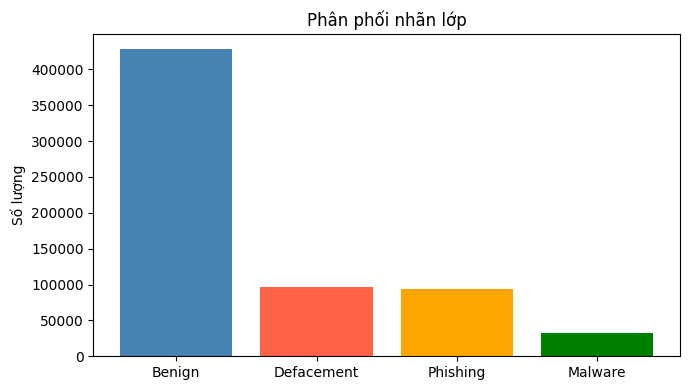

In [35]:
label_map = {0: 'Benign', 1: 'Defacement', 2: 'Phishing', 3: 'Malware'}

print("=== PHÂN PHỐI NHÃN ===")
print(df['label'].value_counts())
print(f"\nTỷ lệ (%):\n{df['label'].value_counts(normalize=True).round(3) * 100}")

plt.figure(figsize=(7, 4))
counts = df['label'].value_counts().sort_index()
plt.bar([label_map[i] for i in counts.index], counts.values,
        color=['steelblue', 'tomato', 'orange', 'green'])
plt.title('Phân phối nhãn lớp')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

## **4. Kiểm Tra Cột Dạng Text**
Dataset có 4 cột text: `url`, `type`, `domain`, `scan_date`.  

- **Với các model Machine Learning:** chỉ học được từ dữ liệu số nên không giữ lại 
  bất kỳ cột dạng text nào khi train.
- **Với các model Deep Learning:** chỉ giữ lại **url**, loại type, domain, scan_date:
  - `domain` bị loại vì chỉ là 1 phần nhỏ trích ra từ url (ví dụ: url = 
    **http://malware-host.xyz/login?user=1**, domain chỉ là **malware-host.xyz**).
  - `type` bị loại vì đây là cột đã bị dán nhãn sẵn nếu đưa vào làm input, 
    model sẽ nhìn thấy kết quả trước khi đưa ra output (data leakage - rò rỉ dữ liệu).
  - `scan_date` bị loại vì không phải đặc điểm cấu trúc của URL chỉ là mốc 
    thời gian quét không giúp phân loại.

In [36]:
print(df.select_dtypes(include='object').columns.tolist())
df.select_dtypes(include='object').head(10)

['url', 'type', 'domain', 'scan_date']


C:\Users\ngoca\AppData\Local\Temp\ipykernel_3336\1728140742.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns.tolist())
C:\Users\ngoca\AppData\Local\Temp\ipykernel_3336\1728140742.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guid

,url,type,domain,scan_date
0,br-icloud.com.br,phishing,br-icloud.com.br,2025-12-03 14:53:31
1,mp3raid.com/music/krizz_kaliko.html,benign,mp3raid.com,2025-12-03 14:53:31
2,bopsecrets.org/rexroth/cr/1.htm,benign,bopsecrets.org,2025-12-03 14:53:31
3,http://garage-pirenne.be/index.php?option=com_...,defacement,garage-pirenne.be,2025-12-03 14:53:31
4,http://adventure-nicaragua.net/index.php?optio...,defacement,adventure-nicaragua.net,2025-12-03 14:53:31
5,http://buzzfil.net/m/show-art/ils-etaient-loin...,benign,buzzfil.net,2025-12-03 14:53:31
6,espn.go.com/nba/player/_/id/3457/brandon-rush,benign,espn.go.com,2025-12-03 14:53:31
7,yourbittorrent.com/?q=anthony-hamilton-soulife,benign,yourbittorrent.com,2025-12-03 14:53:31
8,http://pashminaonline.com/pure-pashminas,defacement,pashminaonline.com,2025-12-03 14:53:31
9,allmusic.com/album/crazy-from-the-heat-r16990,benign,allmusic.com,2025-12-03 14:53:31


## **5. Tạo Pipeline cho dữ Liệu**
Do các model Machine learning truyền thống cần đặc trưng số được trích sẵn thủ công trước khi train, trong khi Deep Learning cho phép trích chọn đặc trưng tự động từ dữ liệu. Dựa trên bản chất của 2 nền tảng trên cần 2 dạng input khác nhau đồng nghĩa với việc chia data thành 2 pipeline riêng.<br>

**Pipeline 1 `df_tab`**:
- Loại 4 cột text(url, type, domain, scan_date)
- Không cần xử lý missing value ở bước này: cột duy nhất có thiếu dữ liệu (domain, 12,223 dòng) đã bị loại ở trên, nên df_tab sau khi drop không còn missing value nào (xác nhận qua Missing values: 0 khi chạy).

**Pipeline 2 `df_seq`**:
- Chỉ giữ url và label vì Deep learning học trực tiếp trên chuỗi ký tự.
- df[['url', 'label']].copy(): đảm bảo df_seq độc lập với df gốc thuận lợi trong quá trình chỉnh sửa hơn.

In [37]:
# Pipeline 1: df_tab dùng cho machine learning
df_tab = df.drop(columns=['url', 'type', 'domain', 'scan_date'])

print("df_tab (ML pipeline)")
print(f"Shape: {df_tab.shape}")
print(f"Missing values: {df_tab.isnull().sum().sum()}")

# Pipeline 2: df_seq dùng cho deep learning
df_seq = df[['url', 'label']].copy()

print(f"\ndf_seq (Deep Learning pipeline)")
print(f"Shape: {df_seq.shape}")
print(f"Missing values: {df_seq.isnull().sum().sum()}")

df_tab (ML pipeline)
Shape: (651191, 60)


Missing values: 0

df_seq (Deep Learning pipeline)
Shape: (651191, 2)
Missing values: 0


## **6. Chia Tập Train / Test**

Chia 80/20. Dùng `stratify=y` để tỷ lệ 4 lớp trong train và test giống nhau, tránh trường hợp một tập bị thiếu hẳn lớp Malware.

In [38]:
X = df_tab.drop(columns=['label'])
y = df_tab['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nTrain label distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))
print(f"\nTest label distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train: (520952, 59)
X_test:  (130239, 59)

Train label distribution (%):
label
0    65.74
1    14.81
2    14.45
3     4.99
Name: proportion, dtype: float64

Test label distribution (%):
label
0    65.74
1    14.81
2    14.45
3     4.99
Name: proportion, dtype: float64


## **7. Chuẩn Hóa Dữ Liệu**

Một số features có giá trị chênh nhau rất lớn (ví dụ `url_len` max = 2175 trong khi nhiều features chỉ là 0/1). Nếu không chuẩn hóa, các model nhạy với khoảng cách như KNN hay SVM sẽ bị ảnh hưởng.

Scaler chỉ `fit` trên **train set**, sau đó `transform` cả hai. Nếu fit trên toàn bộ data là **data leakage** model đã biết thông tin test trước khi đánh giá.

In [39]:
scaler = StandardScaler()

# Fit trên train, transform cả train và test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert lại về DataFrame 
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"X_train_scaled mean (5 cột đầu):\n{X_train_scaled.iloc[:, :5].mean().round(4)}")

X_train_scaled mean (5 cột đầu):
url_len    0.0
@          0.0
?         -0.0
-          0.0
=         -0.0
dtype: float64


## **8. Ma Trận Tương Quan Giữa Các Features**

Với 59 features khi dùng heatmap tên trục sẽ chồng chéo nhau không hiển thị rõ được nội dung cho nên với heatmap này chỉ giúp có cái nhìn tổng quan về phân phối giữa các features (phần lớn ô nhạt màu gần 0 chỉ vài cụm đậm). 

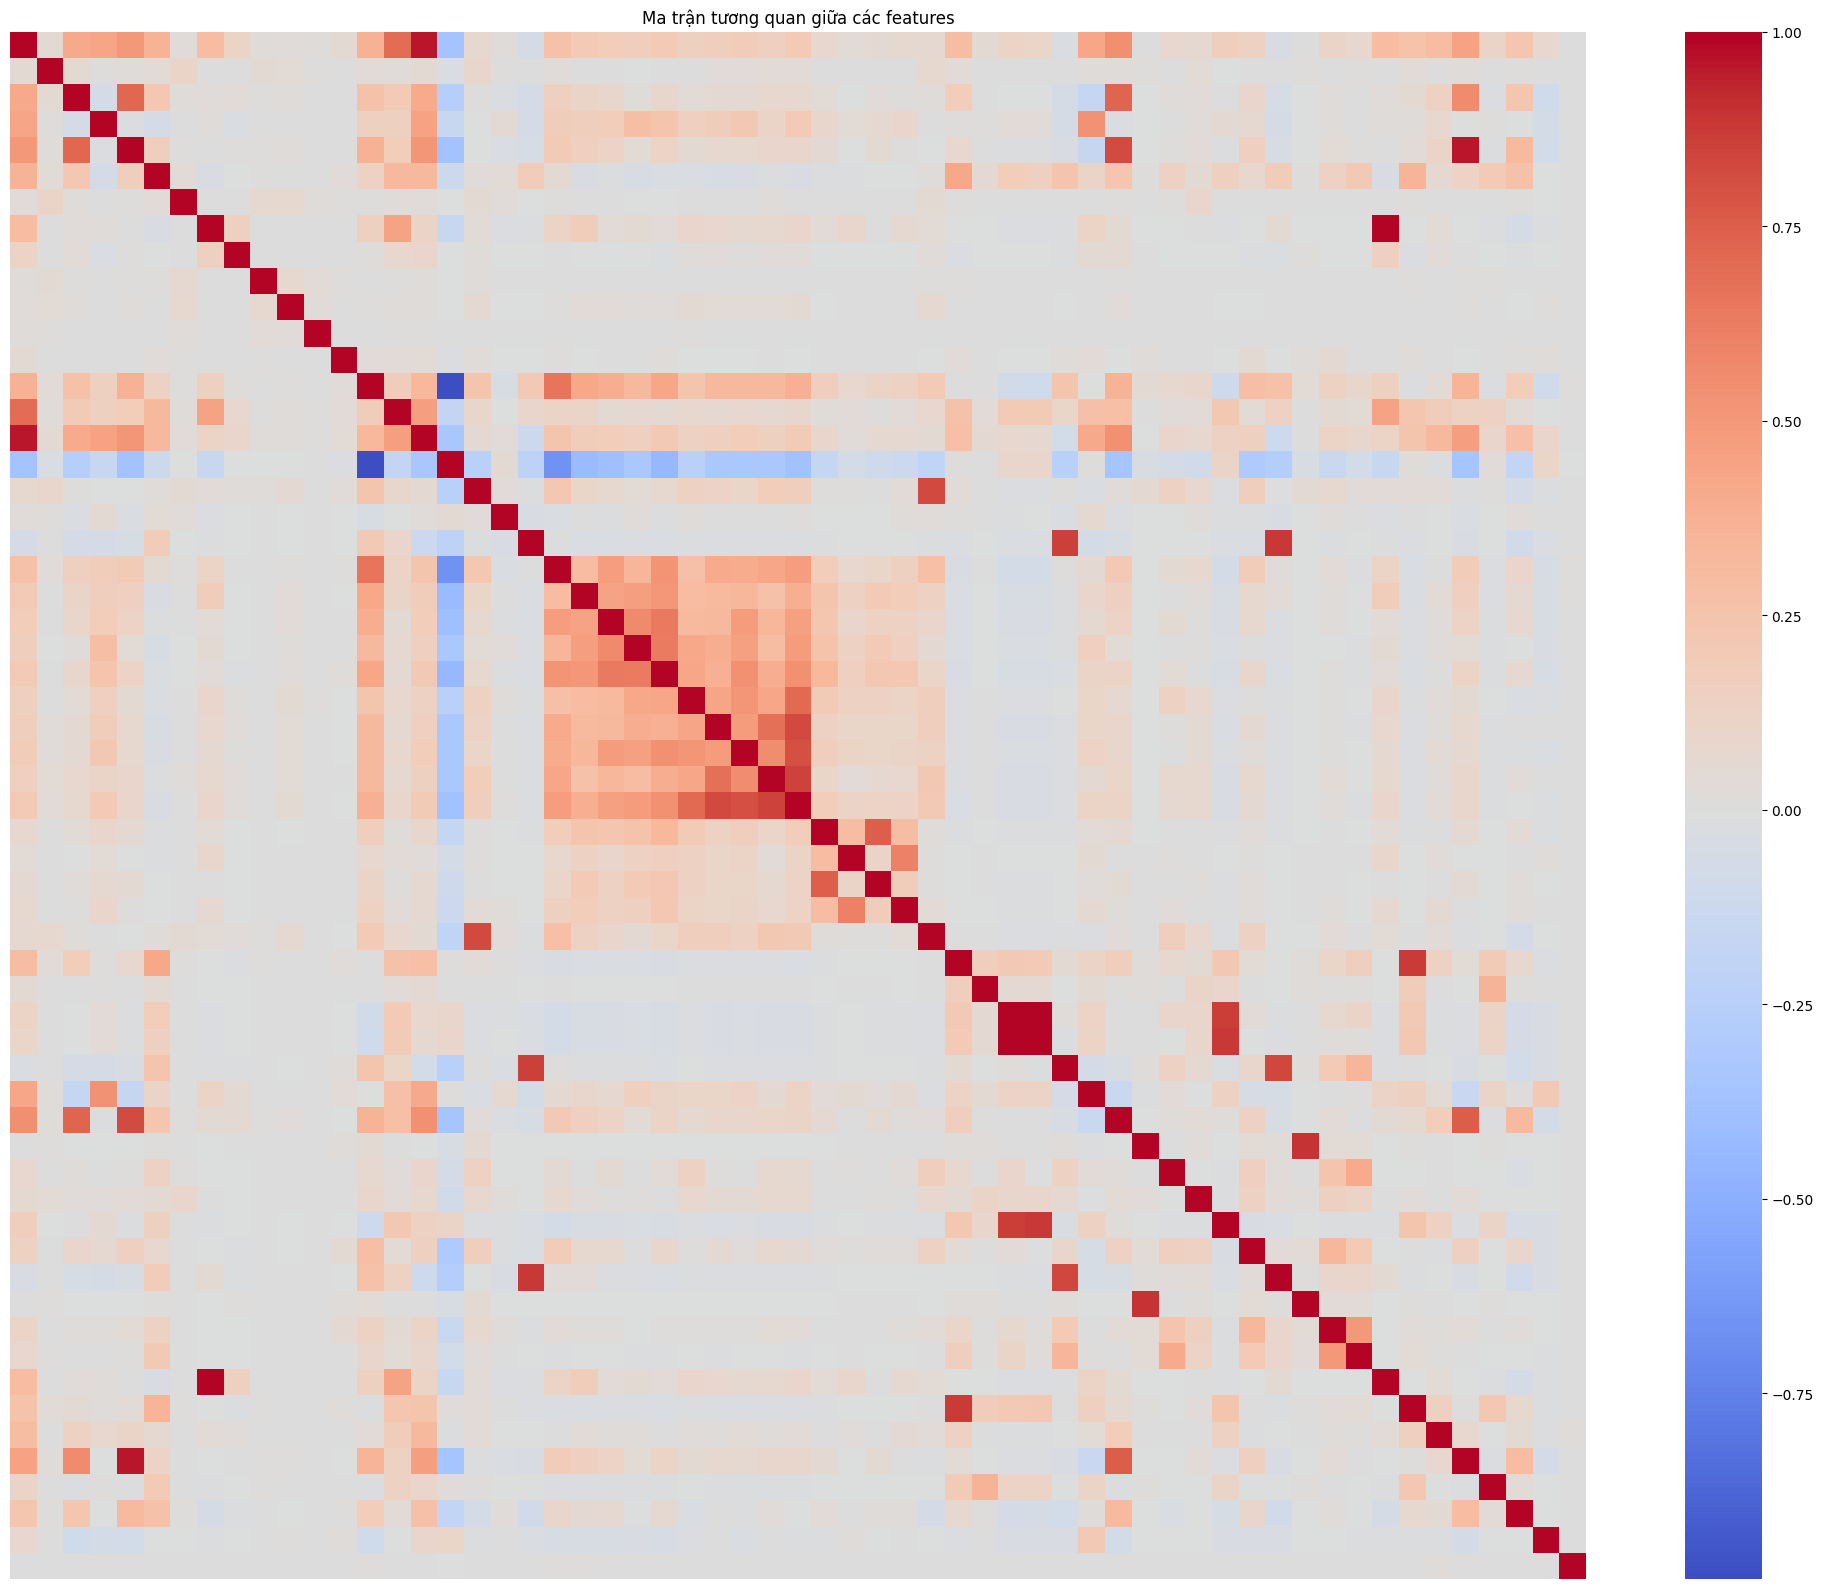

In [40]:
plt.figure(figsize=(20, 16))
corr_matrix = df_tab.drop(columns=['label']).corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False)
plt.title('Ma trận tương quan giữa các features')
plt.tight_layout()
plt.show()

### **Khi truy vấn chi tiết hơn về feature của heatmap**

- **Phát hiện đáng chú ý nhất:** Cột **%** và **phish_adv_encoded_chars** có tương quan tuyệt đối 1.000000 nghĩa là 2 cột này giống nhau trên mọi dòng. Điều này không còn thể hiện ở mức tương quan cao mà là bản sao hoàn toàn của nhau (multicollinearity rất cao).

- **Dấu hiệu composite feature:** Cột **web_security_score** tương quan cao với 4 cột khác bao gồm: web_xcontent 0.85, web_xframe 0.83, web_hsts 0.81, web_csp 
0.71.

- **Trường hợp không phải trùng lặp:** **having_ip_address** với **phish_multiple_subdomains** (0.86) có thể do 2 hành vi này thường đi cùng nhau trong thực tế tấn công (dùng IP thay domain + nhiều subdomain giả), nhưng đây chỉ là giả thuyết dựa trên domain knowledge, chưa được kiểm chứng bằng data như cặp %/ phish_adv_encoded_chars ở trên.

In [41]:
corr = df_tab.drop(columns=['label']).corr()

# Biến ma trận vuông thành 1 danh sách dài các cặp (feature_1, feature_2): giá_trị
corr_pairs = corr.stack()

# Bỏ các dòng mà feature_1 == feature_2 (đường chéo, tự tương quan với chính nó = 1.0, vô nghĩa)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Lọc và sắp xếp
high_corr = corr_pairs[corr_pairs.abs() > 0.6].sort_values(ascending=False)
print(high_corr)
print((df_tab['%'] == df_tab['phish_adv_encoded_chars']).mean())

%                          phish_adv_encoded_chars      1.000000
phish_adv_encoded_chars    %                            1.000000
phish_brand_mentions       phish_brand_hijack           0.987362
phish_brand_hijack         phish_brand_mentions         0.987362
phish_adv_many_params      =                            0.955434
=                          phish_adv_many_params        0.955434
url_len                    letters                      0.953921
letters                    url_len                      0.953921
phish_suspicious_tld       phish_adv_suspicious_tld     0.893159
phish_adv_suspicious_tld   phish_suspicious_tld         0.893159
having_ip_address          phish_adv_number_count       0.882252
phish_adv_number_count     having_ip_address            0.882252
phish_brand_hijack         phish_adv_brand_in_path      0.878222
phish_adv_brand_in_path    phish_brand_hijack           0.878222
phish_adv_path_keywords    phish_urgency_words          0.873751
phish_urgency_words      

## **9. Top 15 Features Tương Quan Cao Nhất Với Nhãn**

Label ở đây là nominal đa lớp (4 lớp, không có thứ tự) nên các phương pháp dựa trên giả định tuyến tính/thứ tự như Pearson không phù hợp để đo liên hệ feature-label kết quả sẽ phụ thuộc vào cách encode nhãn thành số, không phản ánh đúng bản chất dữ liệu. Với numeric feature vs categorical nominal label, lựa chọn hợp lý hơn là ANOVA F-test hoặc Mutual Information. Ở đây dùng `f_classif` vì diễn giải trực quan (so sánh trung bình từng nhóm) và tương thích tốt với pipeline feature selection của sklearn.

**Kết quả:** `abnormal_url`, `//`, `phish_adv_number_count` là 3 feature có 
F-score cao nhất, khá tương đồng với top 5 khi thử tính bằng Pearson cho thấy kết luận "cần tổ hợp nhiều feature, không có feature đơn lẻ nào đủ mạnh" vẫn đúng. 

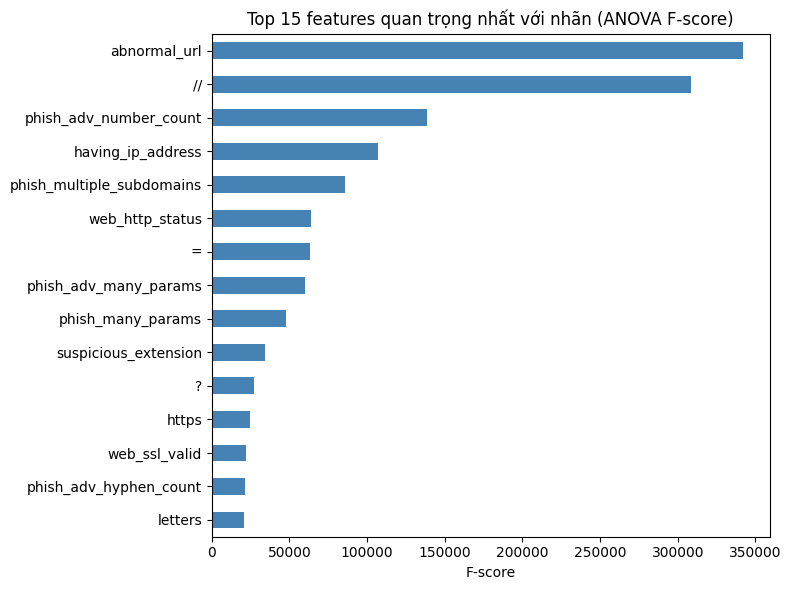

abnormal_url                 342138.703739
//                           308314.502453
phish_adv_number_count       138513.247325
having_ip_address            107048.740151
phish_multiple_subdomains     85517.926831
web_http_status               64167.914461
=                             63030.923903
phish_adv_many_params         59770.772279
phish_many_params             47754.340141
suspicious_extension          34112.520458
?                             27289.570729
https                         24531.591194
web_ssl_valid                 22164.924145
phish_adv_hyphen_count        21040.194157
letters                       20585.479686
dtype: float64


In [42]:
from sklearn.feature_selection import f_classif

X = df_tab.drop(columns=['label'])
y = df_tab['label']

f_scores, p_values = f_classif(X, y)
f_scores_series = pd.Series(f_scores, index=X.columns).sort_values(ascending=False)
top_features = f_scores_series[:15]

plt.figure(figsize=(8, 6))
top_features.plot(kind='barh', color='steelblue')
plt.title('Top 15 features quan trọng nhất với nhãn (ANOVA F-score)')
plt.xlabel('F-score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_features)

## **10. Phân Phối Feature Quan Trọng Theo Từng Lớp**

Nhìn vào giá trị trung bình của top 5 features để xem chúng phân biệt các lớp như thế nào. Nếu các lớp có giá trị khác nhau rõ ràng thì feature đó hữu ích.

- **abnormal_url**: Benign cao nhất (~0.93), tiếp đến Phishing () (~0.74), Defacement/Malware gần 0 điều này cho biết không phải lớp độc hại có giá trị cao nhất.

- **//**: Defacement và Malware cao (~0.97-1.0), Phishing trung bình (~0.27), Benign 
  thấp (~0.08) phân biệt khá rõ giữa nhóm độc hại và Benign.

- **phish_adv_number_count, phish_multiple_subdomains, having_ip_address**: Cả 3 feature đều có chung 1 pattern chỉ lớp Malware đạt giá trị cao chênh lệch giữa 3 lớp còn lại.

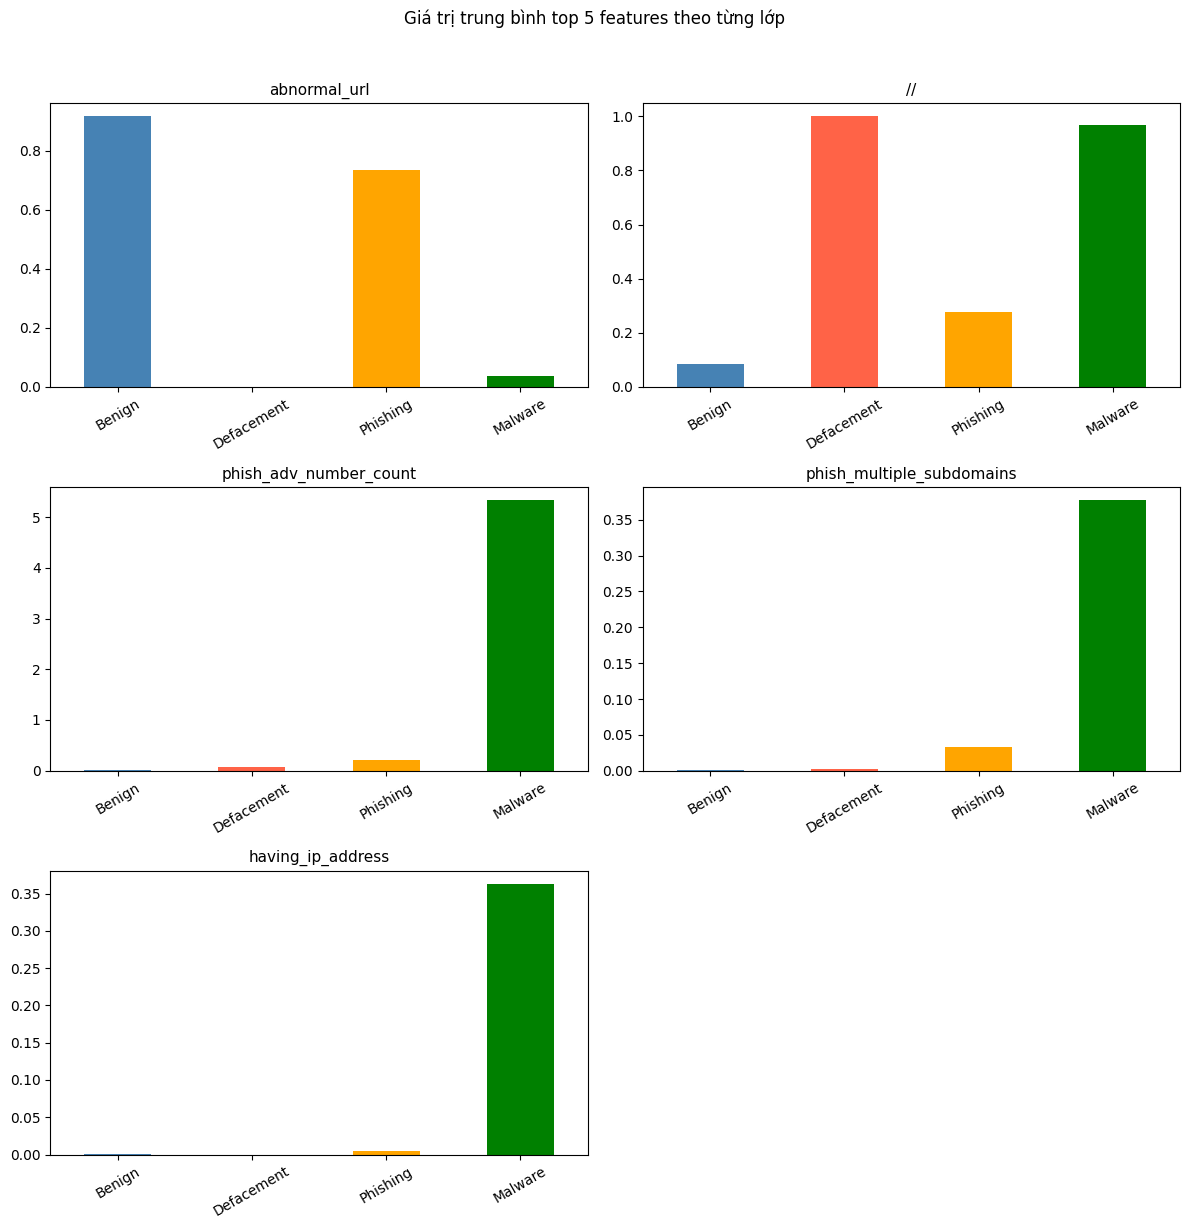

In [43]:
top5 = ['abnormal_url', '//', 'phish_adv_number_count',
        'phish_multiple_subdomains', 'having_ip_address']

label_names = {0: 'Benign', 1: 'Defacement', 2: 'Phishing', 3: 'Malware'}

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, feat in enumerate(top5):
    df_tab.groupby('label')[feat].mean().rename(label_names).plot(
        kind='bar', ax=axes[i], color=['steelblue','tomato','orange','green']
    )
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

axes[5].set_visible(False)

plt.suptitle('Giá trị trung bình top 5 features theo từng lớp', y=1.02)
plt.tight_layout()
plt.show()

## **Tổng kết** 

1. **Mất cân bằng lớp nặng** (Benign 65.7%, Malware chỉ 5%) cần dùng F1-macro song song với Accuracy khi đánh giá model, không chỉ nhìn Accuracy.

2. **Multicollinearity** giữa vài cặp feature (% / phish_adv_encoded_chars trùng lặp hoàn toàn, web_security_score có thể là điểm tổng hợp từ 4 cờ khác) chưa xử lý ở bước này, cân nhắc loại bớt nếu ảnh hưởng tới model mang tính chất tuyến tính.

3. **Không có feature đơn lẻ nào đủ mạnh** để phân loại (F-score cao nhất vẫn cần tổ hợp nhiều feature).

4. **2 pipeline riêng biệt** (**df_tab** cho các model Machine Learning, **df_seq** cho model Deep Learning) đã sẵn sàng để dùng ở Notebook 02 và 03 tương ứng.